<a href="https://colab.research.google.com/github/kelvinwambua/Airplane_Crash_Data/blob/main/Airplane_Crash_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

189989 -Syengo Kelvin Wambua|
187629 - Muegi Chelsea Kwamboka|
Jason Wachira



In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np

file_path = "Airplane_Crashes_and_Fatalities_Since_1908.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "saurograndi/airplane-crashes-since-1908",
    file_path,
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'airplane-crashes-since-1908' dataset.
First 5 records:          Date   Time                            Location  \
0  09/17/1908  17:18                 Fort Myer, Virginia   
1  07/12/1912  06:30             AtlantiCity, New Jersey   
2  08/06/1913    NaN  Victoria, British Columbia, Canada   
3  09/09/1913  18:30                  Over the North Sea   
4  10/17/1913  10:30          Near Johannisthal, Germany   

                 Operator Flight #          Route                    Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1    Military - U.S. Navy      NaN    Test flight               Dirigible   
2                 Private        -            NaN        Curtiss seaplane   
3  Military - German Navy      NaN            NaN  Zeppelin L-1 (airship)   
4  Military - German Navy      NaN            NaN  Zeppelin L-2 (airship)   

  Registration cn/In  Aboard  Fatalities  Ground  \
0          NaN     1     

In [ ]:
num_rows = df.shape[0]
num_cols = df.shape[1]
print(f"Rows: {num_rows}, Columns: {num_cols}")

Rows: 5268, Columns: 13


In [ ]:
print("Last 75 Rows")
print(df.tail(75))

Last 75 Rows
            Date   Time                                           Location  \
5193  03/15/2008  08:15                                     Nbagu, Nigeria   
5194  04/03/2008  11:00                                     Lawa, Suriname   
5195  04/09/2008  23:27                                Bundeena, Australia   
5196  04/11/2008  22:15                                 Chrisinau, Moldova   
5197  04/15/2008  14:30                                        Goma, Congo   
...          ...    ...                                                ...   
5263  05/20/2009  06:30                             Near Madiun, Indonesia   
5264  05/26/2009    NaN                  Near Isiro, DemocratiRepubliCongo   
5265  06/01/2009  00:15  AtlantiOcean, 570 miles northeast of Natal, Br...   
5266  06/07/2009  08:30       Near Port Hope Simpson, Newfoundland, Canada   
5267  06/08/2009    NaN                  State of Arunachal Pradesh, India   

                             Operator Flight #  \


Time  – Fill with Unknown. It's a categorical field, and with over 40% missing there is no reliable way to guess an exact time from other columns, so a placeholder is the safest option.

Location– Fill with Unknown. Missingness is negligible, so a simple placeholder has almost no effect

Operator – Fill with "Unknown". Same reasoning as Location — too little missing data to justify anything more complex.

Flight – Leave as missing, or treat it as its own category.Most non-commercial flights like military, cargo, private never had a flight number, so the absence itself carries meaning.

Route – Fill with Unknown. It's a free-text field with no numeric relationship to other columns, so there's no statistical way to infer it.

Type– Fill with the mode most frequent aircraft type. Missingness is low, and aircraft type can reasonably be approximated with the most common value in the dataset.

Registration – Leave as Unknown. Registration numbers are unique identifiers, similar to a serial number, so they cannot be inferred or imputed from other fields.

cn/ln– Leave as Unknown. Same reasoning as Registration  it's a unique manufacturing identifier with no valid way to guess its value.

Aboard – Impute with the median. It's a numeric field, but the data is right-skewed with a few very large aircraft alongside many small ones, so the median is more robust than the mean.

Fatalities – Impute with the median, for the same reason as Aboard skewed numeric data where the mean would be distorted by outliers.

Ground  – Fill with 0. A missing value here almost certainly means no ground fatalities occurred, since an actual ground death toll would typically have been recorded. Filling with 0 reflects the real-world meaning rather than fabricating a number.

Summary– Fill with No summary available. It's a free text narrative field, so no numeric or mode-based imputation applies.

In [ ]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']]
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
max_fatalities_row = fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]
print(max_fatalities_row)

Date                        03/27/1977
Location      Tenerife, Canary Islands
Aboard                           644.0
Fatalities                       583.0
Name: 2963, dtype: object


In [ ]:

fatality_locations['Survivors'] = fatality_locations['Aboard'] - fatality_locations['Fatalities']

no_fatalities = fatality_locations[fatality_locations['Fatalities'] == 0]
print("Number of crashes with no fatalities:", len(no_fatalities))
no_fatalities.head()

Number of crashes with no fatalities: 58


/tmp/ipykernel_1400/1974127177.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fatality_locations['Survivors'] = fatality_locations['Aboard'] - fatality_locations['Fatalities']


,Date,Location,Aboard,Fatalities,Survivors
108,10/21/1926,English Channel,12.0,0.0,12.0
387,03/05/1936,"Near Tengya, China",6.0,0.0,6.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0,54.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0,25.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0,34.0


In [ ]:
fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)


fatality_locations['Region'] = fatality_locations['Region'].str.strip()
fatality_locations['State/Country'] = fatality_locations['State/Country'].str.strip()

fatality_locations.head()

/tmp/ipykernel_1400/1372829872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)
/tmp/ipykernel_1400/1372829872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)
/tmp/ipykernel_1400/1372829872.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

,Date,Location,Aboard,Fatalities,Survivors,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,0.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,0.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,6.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,0.0,Near Johannisthal,Germany


In [ ]:
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100_fatalities.head()


,Date,Location,Aboard,Fatalities,Survivors,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,61.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,4.0,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,0.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,0.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,0.0,AtlantiOcean,110 miles West of Ireland


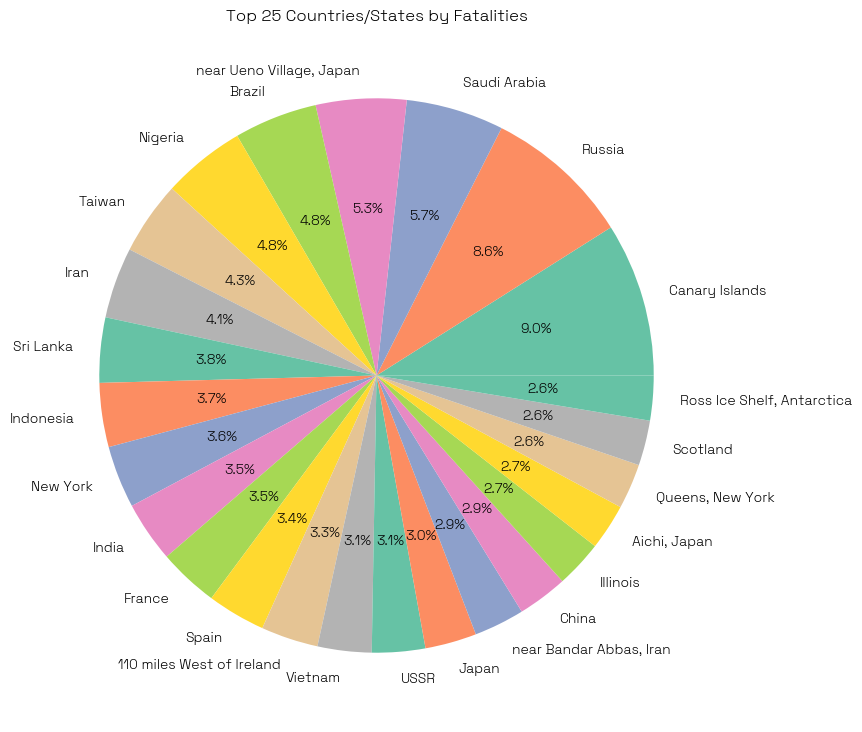

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import urllib.request

urllib.request.urlretrieve(
    "https://github.com/google/fonts/raw/main/ofl/spacegrotesk/SpaceGrotesk%5Bwght%5D.ttf",
    "SpaceGrotesk.ttf"
)
fm.fontManager.addfont("SpaceGrotesk.ttf")
plt.rcParams['font.family'] = 'Space Grotesk'


top_25_grouped = (
    top_100_fatalities.groupby('State/Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)


plt.figure(figsize=(9, 9))
plt.pie(
    top_25_grouped,
    labels=top_25_grouped.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(top_25_grouped))
)
plt.title('Top 25 Countries/States by Fatalities')
plt.show()

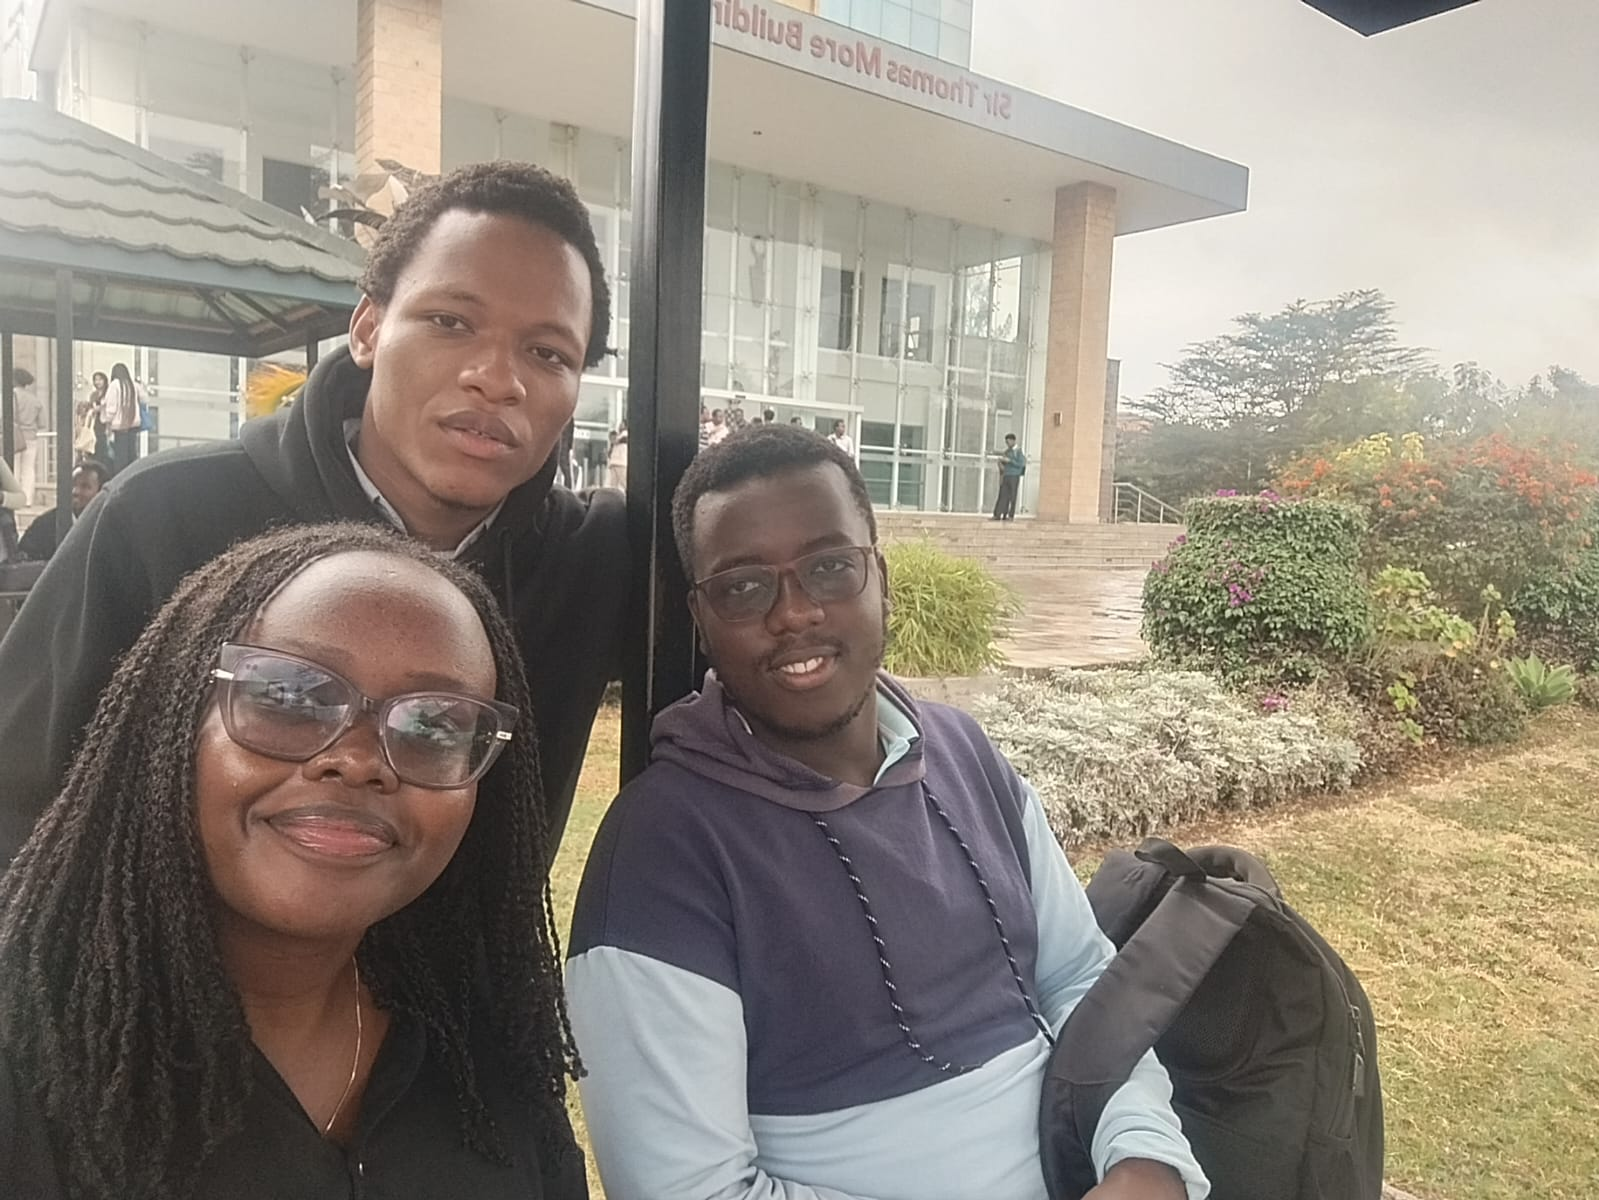